# Elo Model

### Prediction and Update Formulae

Outcomes are given as a number from $0$ to $1$, where $0$ means the player/team on the left lost whilst $1$ means they won. If the outcome is $0.5$, we have a draw, and any number in between represents a win probability.

In [322]:
def expected_outcome(elo_a: float, elo_b: float, scale: int = 400) -> float:
    """
    :param elo_a: First team's elo.
    :param elo_b: Second team's elo.
    :param scale: Elo difference between players to give 10:1 odds to the higher player.
    :return: Chance of player A winning the game.
    """
    rb_ra: float = (elo_b - elo_a) / scale
    return 1 / (1 + 10 ** rb_ra)

In [323]:
def new_elos(elo_a: float, elo_b: float, outcome: float, k_factor: int = 16) -> tuple[float, float]:
    """
    :param elo_a: First team's elo.
    :param elo_b: Second team's elo.
    :param outcome: Which player won. Traditionally it is a simple win/loss, but we use a float that gives information on the margin of victory as well (the fraction of points scored by the first team).
    :param k_factor: Maximum elo change allowed after a game, limiting volatility.
    :return: The updated elos of both players after the game.
    """
    diff: float = k_factor * (outcome - expected_outcome(elo_a, elo_b))
    return elo_a + diff, elo_b - diff

In [324]:
def kelly_criterion(probability: float, odds: float = 2.0) -> float:
    """
    :param probability: The win probability.
    :param odds: Given odds for the team to win. By default, we consider the odds to be even (for backtesting).
    :return: The percentage of the account to bet. With even odds, this is 2p - 1.
    """
    return probability - (1 - probability) / (odds - 1)

### Load Data

First cell formats the raw data and extracts the teams, second cell splits data into training and test.

In [325]:
from pandas import DataFrame
import pandas as pd

raw: DataFrame = pd.read_csv("data/nba_team_reference.csv")
raw["points_ratio"] = raw["pts_home"] / (raw["pts_home"] + raw["pts_away"]) # Tells us which team won and by how much (ratio < 0.5 means home team lost).
raw.drop(columns=["season_year", "team_id_home", "team_id_away", "pts_home", "pts_away", "home_win"], inplace=True) # Formatting the data...
raw.rename(columns={"game_id": "id", "game_date": "date", "team_abbreviation_home": "home", "team_abbreviation_away": "away"}, inplace=True)

teams: dict[str, float] = dict((team, 1000) for team in set(raw["home"].tolist() + raw["away"].tolist())) # Retrieve all team identifiers and start at 1000 elo.

assert len(teams) == 30 # NBA has 30 teams.

In [326]:
# Split data into training (random 80% of games) and test (the remaining 20%). Games will be processed in date order.
training: DataFrame = raw.sample(4 * len(raw) // 5).sort_values(by=["date"])
test:     DataFrame = raw[~raw["id"].isin(training["id"])].sort_values(by=["date"])

assert len(training) + len(test) == len(raw)                     # Check the total number of games is still the same.
assert len(test["id"].isin(training["id"]).value_counts()) == 1  # Ensure no overlap between training and test games.

### Train

Go over each game in order and update team elos.

In [327]:
for row in training.itertuples():
    # For each game, calculate the new elos depending on the result and update the old elos.
    # Using points ratio as opposed to pure win/loss is necessary to ensure strength differences
    # are accurately judged (a slim margin of victory should not cause a large elo change).
    new_home, new_away = new_elos(teams[row.home], teams[row.away], row.points_ratio)
    teams[row.home] = new_home
    teams[row.away] = new_away

# Show teams by elo.
print([ team for team in sorted(teams.items(), key=lambda item: item[1], reverse=True) ])

[('OKC', 1014.4910650867447), ('CLE', 1013.6533155247796), ('BOS', 1011.8486198344942), ('MIN', 1009.9437598167619), ('LAC', 1008.1516043542673), ('IND', 1005.535261361008), ('GSW', 1005.5276700944426), ('NYK', 1005.078556379692), ('MIL', 1004.4246935404899), ('DEN', 1004.3773876463023), ('HOU', 1004.1852160486567), ('MEM', 1002.5702869584727), ('LAL', 1002.1950619798089), ('CHI', 1001.7473729356597), ('DAL', 1001.5612646489618), ('ORL', 1001.5166022993727), ('SAC', 1000.8476024301067), ('DET', 1000.1409601187753), ('ATL', 998.8690068984621), ('MIA', 998.8505961456965), ('POR', 998.2167166665647), ('PHX', 997.0763302553024), ('SAS', 993.290795112962), ('PHI', 992.5277195718709), ('TOR', 992.3207428718148), ('BKN', 989.8355043878046), ('NOP', 988.908409790635), ('UTA', 986.9839600977897), ('CHA', 985.4465265803806), ('WAS', 979.8773905619198)]


### Test

In [328]:
# Calculate expected outcomes and percentage of account to bet for each test game, as well as whether or not the prediction was correct.
predictions: DataFrame = test.copy() # To avoid editing raw test data.
predictions["prob"] = predictions.apply(lambda row: expected_outcome(teams[row["home"]], teams[row["away"]]), axis=1)
predictions.apply(lambda row: kelly_criterion(row["prob"] if row["prob"] > 0.5 else (1 - row["prob"])), axis=1)
predictions["kelly_bet"] = predictions.apply(lambda row: kelly_criterion(row["prob"] if row["prob"] > 0.5 else (1 - row["prob"])), axis=1)
predictions["correct"] = (predictions["points_ratio"] > 0.5) == (predictions["prob"] > 0.5)

#  Calculate account balance at each time step.
kelly_balances: list[float] = [ 10_000.0 ]
for row in predictions.itertuples():
    kelly_balances.append(kelly_balances[-1] + kelly_balances[-1] * row.kelly_bet * (1 if row.correct else -1))

# Calculate win rate and final balance.
success: dict[bool, int] = predictions["correct"].value_counts().to_dict()
print(f"Win Rate: {success[True] / (success[True] + success[False])}, Kelly Balance: {kelly_balances[-1]}")

Win Rate: 0.5484048404840484, Kelly Balance: 4104647.417273269


### Some Graphs For Fun

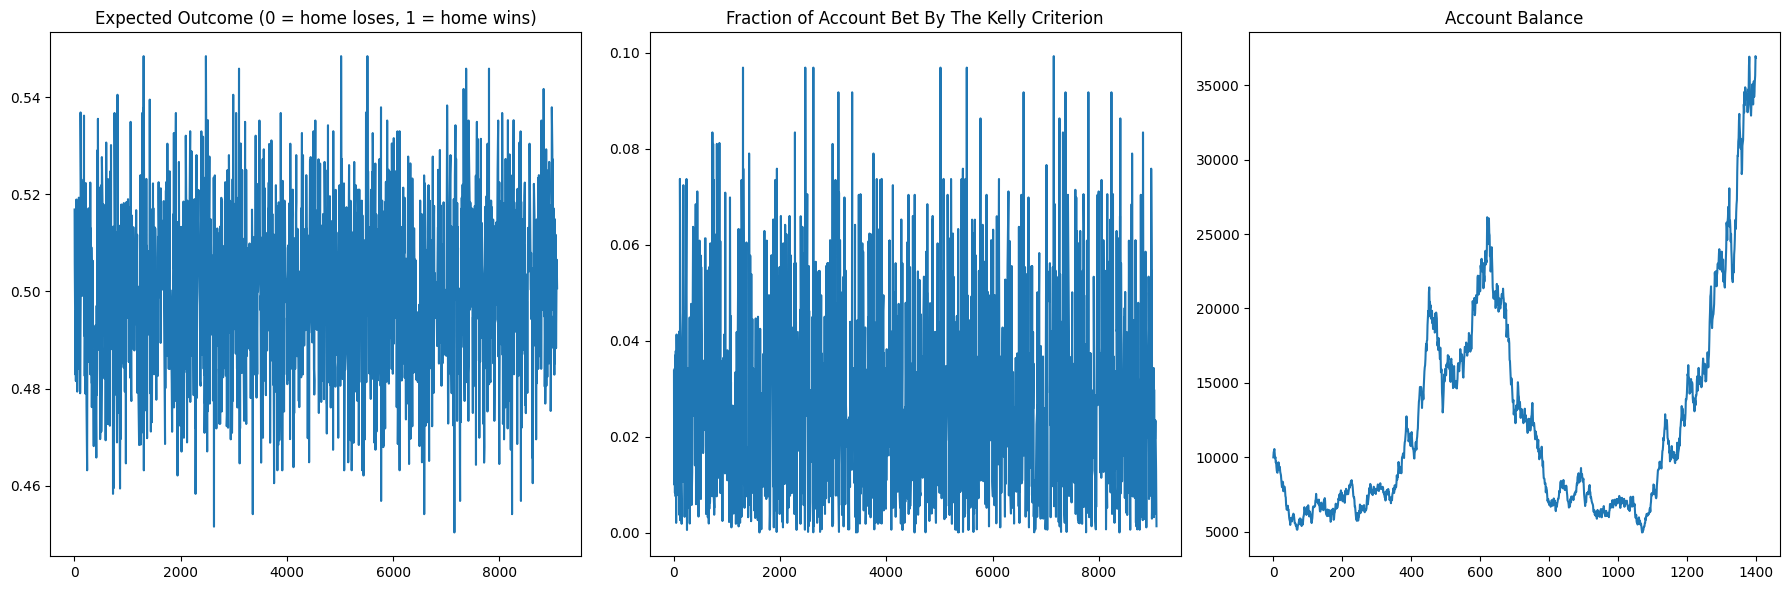

In [329]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

axs[0].plot(predictions.prob)
axs[0].set_title("Expected Outcome (0 = home loses, 1 = home wins)")

axs[1].plot(predictions.kelly_bet)
axs[1].set_title("Fraction of Account Bet By The Kelly Criterion")

axs[2].plot(kelly_balances)
axs[2].set_title("Account Balance")

plt.tight_layout()
plt.show()